# Post-processing tool tutorial

This example illustrates how to use the framework to postprocess the database mimicking the ercoftac database.

**NOTE**:
- The notebook will not run unless you set up the directories for the simulations result and the experiments, if you are not interested in comparing with the
experiments, you can comment the lines.
- The experimental data can be found on [ERCOFTAC T3-](http://cfd.mace.manchester.ac.uk/ercoftac/doku.php?id=cases:case020)


In [1]:
import os
import warnings
import json
#
import numpy                    as np
import matplotlib.pyplot        as plt
from matplotlib.ticker          import ScalarFormatter
from  interface                 import PostProcessMusicaa
from ppModule.readExp.ercoftac  import ReadErcoftac
# To plot acceelration factor for T3C- cases
from utils                      import read_acceleration_factor, compute_tu
warnings.filterwarnings('ignore')

## 1. Initiate postprocessing object:

In [2]:
# Load configuration file
casename = 't3c2'
with open(f'config.json') as json_file:
    config = json.load(json_file)

# Initialize post-processing module
pp = PostProcessMusicaa(config=config[casename]["ppMusicaa"])
#
tauw = pp.compute_qty(qty="tauw")[2]
stats= pp.return_stats()[2]
Ue   = stats["ufst"]
Cf   = stats["cf"]

#
rex_num = Ue*pp.config["grid"]["x"][2][:,0]*stats["rho_fst"]/pp.info["Muref"]



In compute wall normal


#### 1.1. Load normalization quantities, for better comparison with experiments:

In [3]:
#
rex_cf_min = config[casename]["rex_cf_min"]
rex_cf_max = config[casename]["rex_cf_max"]
Uin_exp    = config[casename]["Uin_exp"]
Uin_num    = config[casename]["Uin_num"]
# Normalize reynolds number:
rex_norm= (rex_num - rex_cf_min) / (rex_cf_max - rex_cf_min)


#### 1.2. Set up some parameters for figures:

In [4]:
title_size  = 20
label_size  = 20
axis_size   = 18
xmin, xmax  = config[casename]["xmin"], config[casename]["xmax"]

## 2. Load experimental data:

In [5]:
# Mean data along x-axis
mean_data = ReadErcoftac.read_summary_file_to_dict(filename=os.path.join(config[casename]["exp_path"], "summary.txt"))
rex_exp   = [(mean_data["REX"][i] - rex_cf_min) / (rex_cf_max - rex_cf_min) for i in range(len(mean_data["REX"]))]
#


## 3. Post-process results

- For the T3C- cases, plot the freestream velocity normalized by the inlet velocity to comare with experiments and the acceleration factor

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


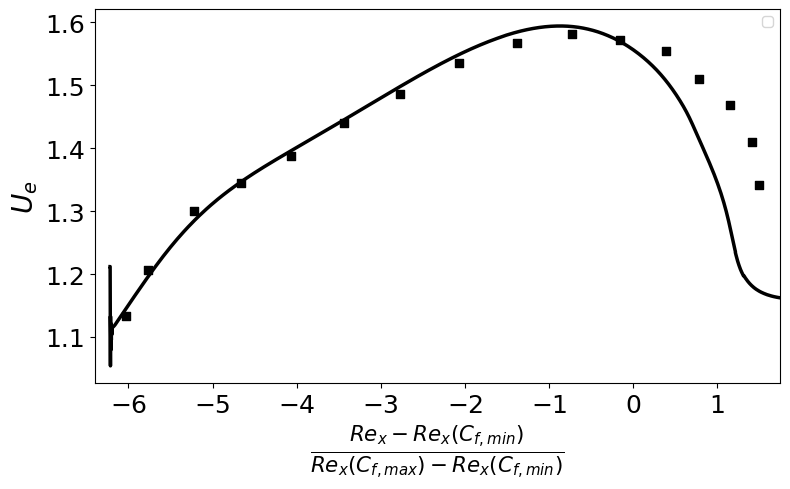

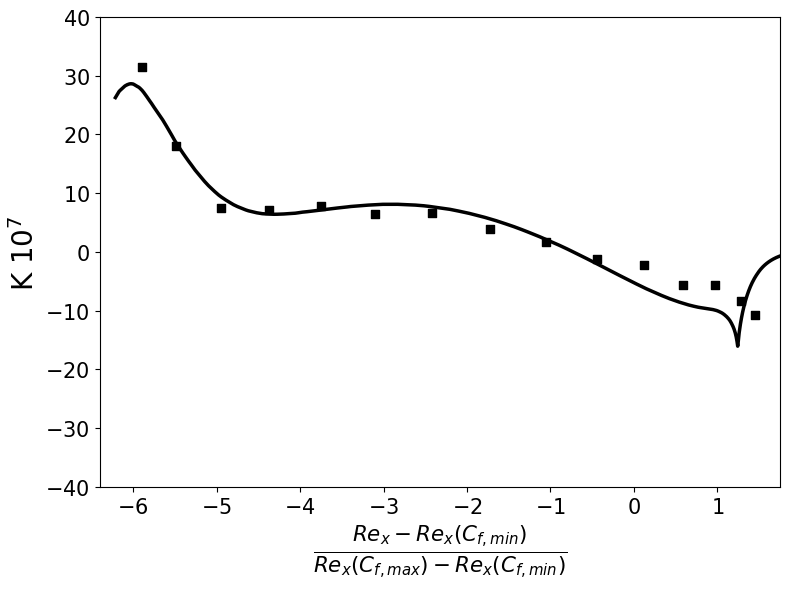

In [6]:
def contains_substring(string, substring):
    return substring in string
#
if contains_substring(casename.upper(), "T3C"):
    # Edge velocity over inlet velocity
    plt.figure(figsize=(8,5))
    plt.plot(rex_norm, Ue/Uin_num, color="black", linewidth=2.5)
    plt.scatter(rex_exp, np.array(mean_data["UO"])/Uin_exp, color="black", marker="s")
    plt.xlabel(r"$\frac{Re_x - Re_x(C_{f,min})}{Re_x(C_{f,max}) - Re_x(C_{f,min})}$"   , fontsize=22)
    plt.ylabel(r"$U_e$", fontsize=label_size)
    plt.tick_params(axis="both", which="major", labelsize=axis_size)
    plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    plt.gca().xaxis.get_offset_text().set_fontsize(16)
    plt.legend()
    plt.xlim(left=xmin, right=xmax) # Adjust for each case
    # plt.ylim(bottom=1.4, top=1.75)
    plt.tight_layout()
    # Plot acceleration factor:
    data_num = read_acceleration_factor(file_path="/home/louenas/Documents/phd/4-results/cases/ercoftac/t3c2/figures/acceleration_factor.dat")
    data_exp = read_acceleration_factor(file_path="/home/louenas/Documents/phd/4-results/cases/ercoftac/t3c2/figures/acceleration_factor_exp.dat")
    plt.figure(figsize=(8,6))
    plt.plot(data_num["rex"], data_num["k"]*1e7, color="black", linewidth=2.5)
    plt.scatter(data_exp["rex"], data_exp["k"]*1e7, color="black", marker="s")
    plt.xlabel(r"$\frac{Re_x - Re_x(C_{f,min})}{Re_x(C_{f,max}) - Re_x(C_{f,min})}$", fontsize=22)
    plt.ylabel(r"K $10^{7}$", fontsize=label_size)
    plt.ylim(-40. , 40.)
    # plt.grid(True)
    plt.xlim(left=xmin, right=xmax)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    plt.gca().ticklabel_format(axis='x', style='sci', scilimits=(0,0))
    plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    plt.tight_layout()

    

- Plot the freestream turbulent intensity:

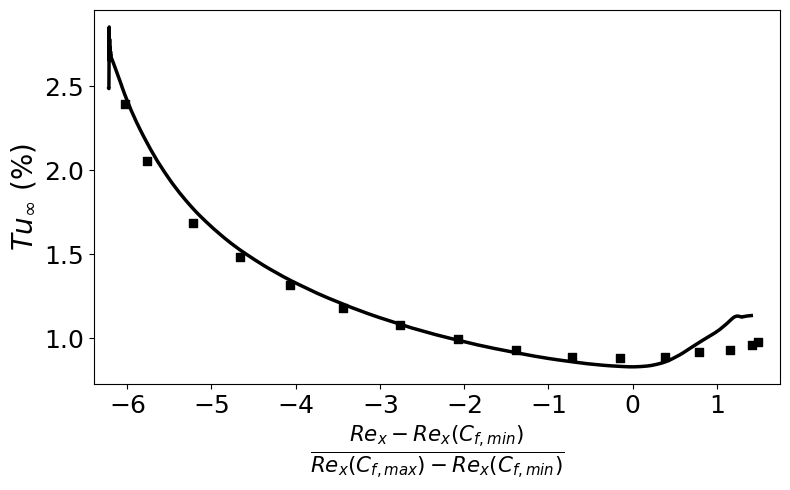

In [7]:
tu = compute_tu(stats=stats, jmin=config[casename]["jmin_tu"], jmax=config[casename]["jmax_tu"], ue=Ue)

plt.figure(figsize=(8,5))
plt.plot(rex_norm[:-50], tu[:-50], color="black", linewidth=2.5) # 50 last points are the sponge zone, ignore them
plt.scatter(rex_exp, mean_data["TUFS"], color="black", marker="s")
plt.xlabel(r"$\frac{Re_x - Re_x(C_{f,min})}{Re_x(C_{f,max}) - Re_x(C_{f,min})}$", fontsize=22)
plt.ylabel(r"$Tu_{\infty}$ (%)", fontsize=label_size)
# plt.ylim(0., 3.5)
plt.xlim(left=xmin, right=xmax)
plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.gca().ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.tight_layout() 

- Plot the skin friction coefficient:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


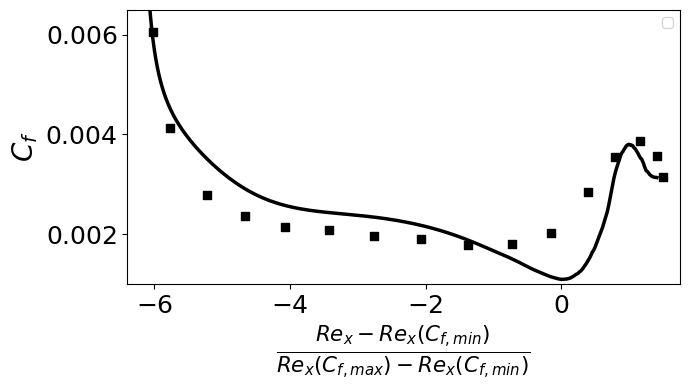

In [8]:
plt.figure(figsize=(7,4))
plt.plot(rex_norm[:-50], Cf[:-50], color="black", linewidth=2.5)
plt.scatter(rex_exp, mean_data["CF"], color="black", marker="s")
plt.xlabel(r"$\frac{Re_x - Re_x(C_{f,min})}{Re_x(C_{f,max}) - Re_x(C_{f,min})}$", fontsize=22)
plt.ylabel(r"$C_f$", fontsize=label_size)
plt.tick_params(axis="both", which="major", labelsize= axis_size)
plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis="x", scilimits=(0, 0))
plt.gca().xaxis.get_offset_text().set_fontsize(16)
plt.ylim(0.001, 0.0065) # Adjust for each case  
plt.xlim(left=xmin, right=xmax)
plt.legend()
plt.tight_layout()

## 4. To go further

This database has been generated to provide reference data to improve lower fidelity transitional models, one of the main interest of the database is the access to full fields of fluctuating stress tensir as will be shown below. However, to plot the wall normal profiles, we advise the user to interpolate the data into a cartesian mesh, as the grid used for the T3C- cases is not cartesian.

To access the fluctuating tensor:

In [9]:
u_rms = stats["u_rms"]
v_rms = stats["v_rms"]
w_rms = stats["w_rms"]
uv_rms= stats["uv_rms"]
uw_rms= stats["uw_rms"]
vw_rms= stats["vw_rms"]